# Lista de Exercícios — Implementando o Perceptron

**Disciplina:** Inteligência Artificial  
**Prof. Me. Gabriel Duarte**  
**Aluna:** Alane Damasceno Moreno  

## Objetivo
Nesta atividade implementei **do zero, em NumPy puro, o Perceptron de Rosenblatt**, usando a regra:

\[
w \leftarrow w + \alpha (y-\hat{y})x
\]

\[
b \leftarrow b + \alpha (y-\hat{y})
\]

O algoritmo será testado nas portas **OR, AND e XOR** e, ao final, nas classes setosa e versicolor da base **Iris**. O `sklearn` será usado somente para carregar a Iris.

# 1. Configuração

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

np.set_printoptions(precision=4, suppress=True)
print("NumPy:", np.__version__)

NumPy: 2.1.3


## 1.1 Portas lógicas

In [75]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_or  = np.array([0,1,1,1], dtype=float)
y_and = np.array([0,0,0,1], dtype=float)
y_xor = np.array([0,1,1,0], dtype=float)

print("X:\n", X)
print("OR :", y_or)
print("AND:", y_and)
print("XOR:", y_xor)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
OR : [0. 1. 1. 1.]
AND: [0. 0. 0. 1.]
XOR: [0. 1. 1. 0.]


# 2. Implementação manual do Perceptron

Uso `ŷ = 1` quando `z >= 0` e `ŷ = 0` caso contrário. Os pesos começam em zero e as amostras são percorridas em ordem fixa.

In [76]:
def degrau(z):
    return 1.0 if z >= 0 else 0.0

def predizer(X, w, b):
    return (X @ w + b >= 0).astype(float)

def treina_perceptron(X, y, alpha=1.0, max_epocas=50):
    w = np.zeros(X.shape[1], dtype=float)
    b = 0.0
    erros = []

    for epoca in range(max_epocas):
        erros_epoca = 0

        for i in range(len(X)):
            z = np.dot(w, X[i]) + b
            pred = degrau(z)
            erro = y[i] - pred

            if erro != 0:
                w = w + alpha * erro * X[i]
                b = b + alpha * erro
                erros_epoca += 1

        erros.append(erros_epoca)

        if erros_epoca == 0:
            break

    return w, b, erros

# 3. Exercício 1 — Porta OR

## 3.1 Pontos da OR

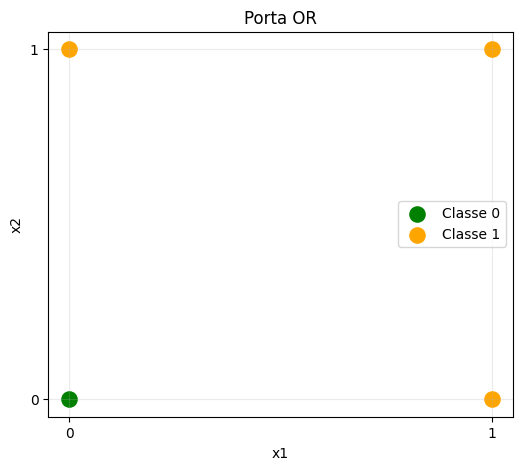

In [77]:
plt.figure(figsize=(6,5))
plt.scatter(X[y_or==0,0], X[y_or==0,1], c="green", s=120, label="Classe 0")
plt.scatter(X[y_or==1,0], X[y_or==1,1], c="orange", s=120, label="Classe 1")
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Porta OR")
plt.xticks([0,1]); plt.yticks([0,1]); plt.grid(alpha=.25); plt.legend()
plt.show()

## 3.2 Antes de rodar — cálculo manual

Para `(0,0)`, começando com `w=(0,0)` e `b=0`, temos `z=0`. Como a regra usa `z >= 0`, a previsão é `1`, mas o correto é `0`. O erro é `-1`; os pesos permanecem `(0,0)` porque a entrada é nula, e o bias passa para `-1`.

Na amostra seguinte, `(0,1)`, temos `z=-1`, então a previsão é `0`, mas o correto é `1`. O erro é `+1`; o peso passa para `(0,1)` e o bias volta a `0`.

In [78]:
w_manual = np.zeros(2)
b_manual = 0.0

for i in [0,1]:
    z = np.dot(w_manual, X[i]) + b_manual
    pred = degrau(z)
    erro = y_or[i] - pred
    print(f"x={X[i]}, z={z}, pred={pred}, y={y_or[i]}, erro={erro}")
    if erro != 0:
        w_manual += erro * X[i]
        b_manual += erro
    print("Após atualização: w =", w_manual, "b =", b_manual)

x=[0. 0.], z=0.0, pred=1.0, y=0.0, erro=-1.0
Após atualização: w = [0. 0.] b = -1.0
x=[0. 1.], z=-1.0, pred=0.0, y=1.0, erro=1.0
Após atualização: w = [0. 1.] b = 0.0


## 3.3 Treinamento da OR

In [79]:
w_or, b_or, erros_or = treina_perceptron(X, y_or)
pred_or = predizer(X, w_or, b_or)
acc_or = np.mean(pred_or == y_or)

print("Erros:", erros_or)
print("w:", w_or, "| b:", b_or)
print("Previsões:", pred_or)
print("Acurácia:", acc_or)
print("Época de convergência:", len(erros_or) if erros_or[-1] == 0 else "não convergiu")

Erros: [2, 2, 1, 0]
w: [1. 1.] | b: -1.0
Previsões: [0. 1. 1. 1.]
Acurácia: 1.0
Época de convergência: 4


### Resposta
Com as configurações pedidas, a OR deve produzir **`[2, 2, 1, 0]`**, convergindo na **4ª época**, com `w=(1,1)` e `b=-1`.

## 3.4 Erros × época

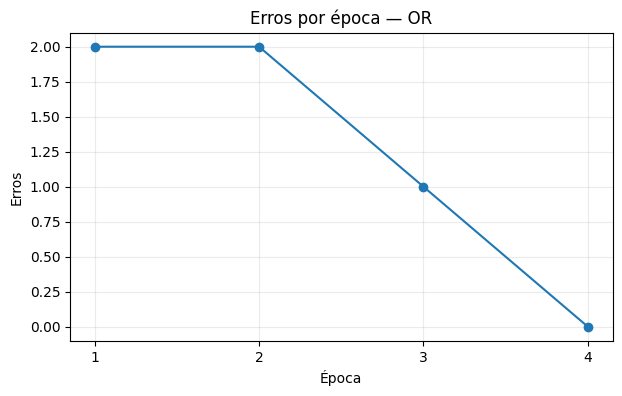

In [80]:
plt.figure(figsize=(7,4))
plt.plot(range(1,len(erros_or)+1), erros_or, marker="o")
plt.xticks(range(1,len(erros_or)+1))
plt.xlabel("Época"); plt.ylabel("Erros"); plt.title("Erros por época — OR")
plt.grid(alpha=.25); plt.show()

## 3.5 Fronteira final

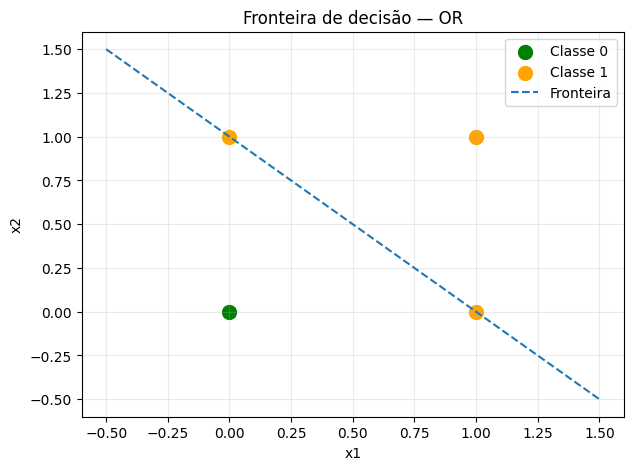

In [81]:
def plotar_fronteira(X, y, w, b, titulo, xlabel="x1", ylabel="x2"):
    plt.figure(figsize=(7,5))
    plt.scatter(X[y==0,0], X[y==0,1], c="green", s=100, label="Classe 0")
    plt.scatter(X[y==1,0], X[y==1,1], c="orange", s=100, label="Classe 1")
    xx = np.linspace(X[:,0].min()-.5, X[:,0].max()+.5, 200)
    if abs(w[1]) > 1e-12:
        yy = -(w[0]*xx + b)/w[1]
        plt.plot(xx, yy, "--", label="Fronteira")
    elif abs(w[0]) > 1e-12:
        plt.axvline(-b/w[0], linestyle="--", label="Fronteira")
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(titulo)
    plt.grid(alpha=.25); plt.legend(); plt.show()

plotar_fronteira(X, y_or, w_or, b_or, "Fronteira de decisão — OR")

# 4. Exercício 2 — Porta AND

In [82]:
w_and, b_and, erros_and = treina_perceptron(X, y_and)
pred_and = predizer(X, w_and, b_and)
acc_and = np.mean(pred_and == y_and)

print("Erros:", erros_and)
print("w:", w_and, "| b:", b_and)
print("Previsões:", pred_and)
print("Acurácia:", acc_and)
print("Época de convergência:", len(erros_and) if erros_and[-1] == 0 else "não convergiu")

Erros: [2, 3, 3, 2, 1, 0]
w: [2. 1.] | b: -3.0
Previsões: [0. 0. 0. 1.]
Acurácia: 1.0
Época de convergência: 6


### Resposta — comparação OR × AND
A AND converge, mas neste experimento precisa de mais épocas que a OR. O resultado esperado é **`[2,3,3,2,1,0]`**, com convergência na **6ª época**, `w=(2,1)` e `b=-3`.

O número de atualizações depende não apenas de o conjunto ser separável, mas também da posição inicial da fronteira e da ordem das amostras. Com pesos e bias inicialmente nulos, a configuração da AND exige mais correções até que somente `(1,1)` fique no lado correspondente à classe 1.

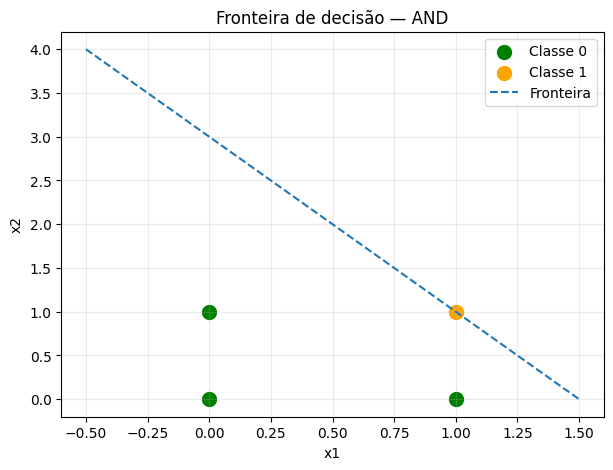

In [83]:
plotar_fronteira(X, y_and, w_and, b_and, "Fronteira de decisão — AND")

# 5. Exercício 3 — XOR

O XOR não é linearmente separável: `(0,0)` e `(1,1)` pertencem à classe 0, enquanto `(0,1)` e `(1,0)` pertencem à classe 1. Não existe uma única reta que separe as duas classes.

In [84]:
w_xor, b_xor, erros_xor = treina_perceptron(X, y_xor, max_epocas=50)
pred_xor = predizer(X, w_xor, b_xor)
acc_xor = np.mean(pred_xor == y_xor)

print("Erros nas 50 épocas:", erros_xor)
print("Convergiu?", erros_xor[-1] == 0)
print("w:", w_xor, "| b:", b_xor)
print("Previsões:", pred_xor)
print("Acurácia final:", acc_xor)

Erros nas 50 épocas: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Convergiu? False
w: [-1.  0.] | b: 0.0
Previsões: [1. 1. 0. 0.]
Acurácia final: 0.5


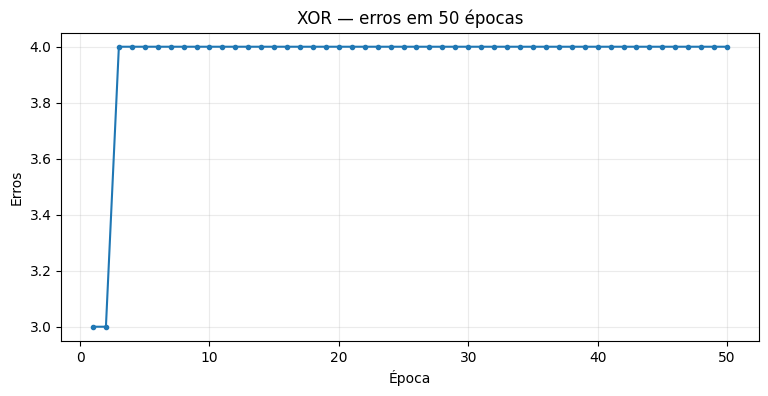

In [85]:
plt.figure(figsize=(9,4))
plt.plot(range(1,len(erros_xor)+1), erros_xor, marker="o", markersize=3)
plt.xlabel("Época"); plt.ylabel("Erros"); plt.title("XOR — erros em 50 épocas")
plt.grid(alpha=.25); plt.show()

## 5.1 Oscilação por 1000 épocas

In [86]:
w_xor_1000, b_xor_1000, erros_xor_1000 = treina_perceptron(
    X, y_xor, max_epocas=1000
)
pred_xor_1000 = predizer(X, w_xor_1000, b_xor_1000)
acc_xor_1000 = np.mean(pred_xor_1000 == y_xor)

print("Épocas executadas:", len(erros_xor_1000))
print("Alguma época teve 0 erros?", 0 in erros_xor_1000)
print("Menor número de erros:", min(erros_xor_1000))
print("Acurácia final:", acc_xor_1000)
print("Últimas 20 épocas:", erros_xor_1000[-20:])

Épocas executadas: 1000
Alguma época teve 0 erros? False
Menor número de erros: 3
Acurácia final: 0.5
Últimas 20 épocas: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


### Resposta — por que treinar mais ou aumentar α não resolve?
O problema do XOR não é falta de tempo de treinamento, mas a geometria das classes. Um Perceptron simples só consegue representar uma fronteira linear, e não existe uma reta que separe corretamente o XOR. Aumentar `α` apenas aumenta o tamanho das atualizações, sem criar uma solução linear inexistente. Assim, o algoritmo continua oscilando. O Teorema de Convergência do Perceptron explica esse comportamento: a garantia de convergência vale para conjuntos linearmente separáveis.

# 6. Exercício 4 — Desafio com Iris

In [87]:
iris = load_iris()
mask = (iris.target == 0) | (iris.target == 1)

Xb = iris.data[mask][:, [2,3]]
yb = (iris.target[mask] == 1).astype(float)

print("Xb:", Xb.shape)
print("yb:", yb.shape)

Xb: (100, 2)
yb: (100,)


## 6.1 Visualização

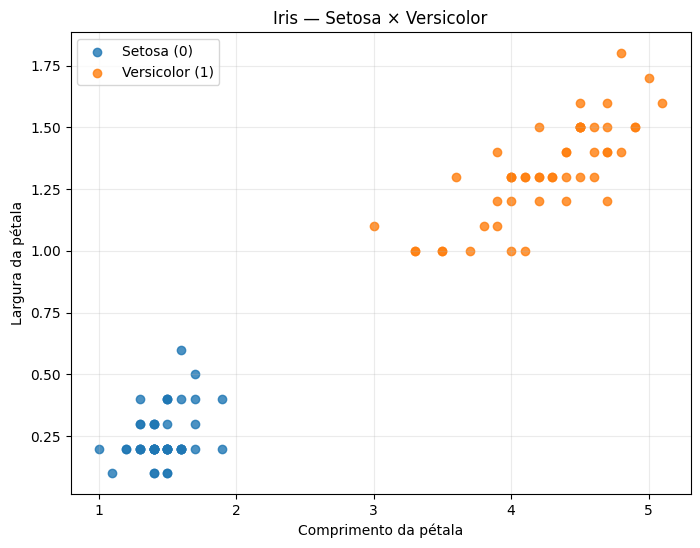

In [88]:
plt.figure(figsize=(8,6))
plt.scatter(Xb[yb==0,0], Xb[yb==0,1], label="Setosa (0)", alpha=.8)
plt.scatter(Xb[yb==1,0], Xb[yb==1,1], label="Versicolor (1)", alpha=.8)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.title("Iris — Setosa × Versicolor")
plt.grid(alpha=.25); plt.legend(); plt.show()

### Resposta — separabilidade
Visualmente, os dois grupos são linearmente separáveis. A setosa ocupa uma região de pétalas menores, enquanto a versicolor aparece em uma faixa de valores maiores. É possível imaginar uma reta entre os grupos sem atravessar as classes.

## 6.2 Treinamento na Iris

In [89]:
w_iris, b_iris, erros_iris = treina_perceptron(Xb, yb, alpha=1.0, max_epocas=50)
pred_iris = predizer(Xb, w_iris, b_iris)
acc_iris = np.mean(pred_iris == yb)

print("Erros:", erros_iris)
print("w:", w_iris, "| b:", b_iris)
print("Acurácia:", acc_iris)
print("Época de convergência:", len(erros_iris) if erros_iris[-1] == 0 else "não convergiu")

Erros: [2, 2, 0]
w: [0.5 0.8] | b: -2.0
Acurácia: 1.0
Época de convergência: 3


### Resultado esperado
Com a ordem original da Iris e as configurações do enunciado, o esperado é convergir na **3ª época**, com `w ≈ (0.5, 0.8)`, `b=-2` e acurácia `1.0`.

## 6.3 Fronteira na Iris

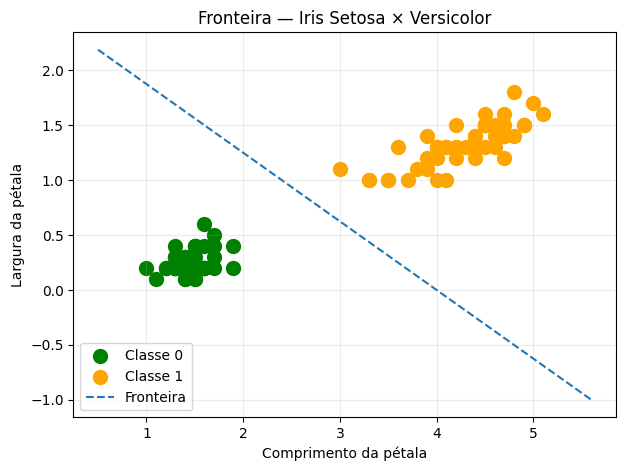

In [90]:
plotar_fronteira(
    Xb, yb, w_iris, b_iris,
    "Fronteira — Iris Setosa × Versicolor",
    "Comprimento da pétala",
    "Largura da pétala"
)

# 7. Comparação geral

In [91]:
resultados = pd.DataFrame({
    "Problema": ["OR", "AND", "XOR", "Iris"],
    "Linearmente separável": ["Sim", "Sim", "Não", "Sim"],
    "Convergiu": [
        erros_or[-1] == 0,
        erros_and[-1] == 0,
        erros_xor[-1] == 0,
        erros_iris[-1] == 0
    ],
    "Épocas": [len(erros_or), len(erros_and), len(erros_xor), len(erros_iris)],
    "Acurácia final": [acc_or, acc_and, acc_xor, acc_iris]
})
display(resultados)

,Problema,Linearmente separável,Convergiu,Épocas,Acurácia final
0,OR,Sim,True,4,1.0
1,AND,Sim,True,6,1.0
2,XOR,Não,False,50,0.5
3,Iris,Sim,True,3,1.0


# 8. Reflexão final

Os resultados deixam clara a principal condição de uso do Perceptron: **as classes precisam ser linearmente separáveis**. OR e AND possuem uma reta capaz de separar seus exemplos e, por isso, o algoritmo converge. O mesmo ocorre com setosa e versicolor na Iris usando comprimento e largura da pétala.

O XOR mostra a limitação do modelo: as classes estão intercaladas e nenhuma única reta consegue separá-las, então o treinamento não converge mesmo aumentando muito o número de épocas. Isso também ajuda a entender a evolução para redes **multicamadas (MLP)**: combinando vários neurônios e transformações não lineares, torna-se possível representar fronteiras mais complexas que um único Perceptron não consegue aprender.

# 9. Autochecagem

| Problema | Resultado esperado |
| --- | --- |
| OR | 4 épocas; erros `[2,2,1,0]`; `w=(1,1)`; `b=-1` |
| AND | 6 épocas; erros `[2,3,3,2,1,0]`; `w=(2,1)`; `b=-3` |
| XOR | Não converge; acurácia aproximadamente `0.5` |
| Iris | 3 épocas; `w≈(0.5,0.8)`; `b=-2`; acurácia `1.0` |

# 10. Checklist
- [x] Perceptron do zero em NumPy
- [x] OR: cálculo manual, treinamento, erros e fronteira
- [x] AND: treinamento, fronteira e comparação com OR
- [x] XOR: 50 e 1000 épocas, acurácia e explicação
- [x] Iris: visualização, treinamento, acurácia e fronteira
- [x] Reflexão final sobre separabilidade e MLP
- [x] Respostas escritas em PT-BR
- [x] Notebook organizado para Google Colab